# fit() vs. fit_transform(), and the Anatomy of Data Leakage

### A teaching notebook on the scikit-learn estimator interface and a dramatic, real demonstration of feature-selection leakage

Two scikit-learn method names — `fit()` and `fit_transform()` — encode a methodological
principle with real scientific consequences: the **separation between learning parameters and
applying them**. Used incorrectly, this single distinction is responsible for what one
large-scale audit estimates affects the large majority of machine-learning papers in a 329-paper,
17-discipline review (Kapoor & Narayanan, 2023). This notebook explains the API precisely, derives
the leakage taxonomy these methods sit inside, and then runs the most dramatic and well-documented
leakage demonstration in the literature ourselves: feature selection performed on pure random
noise, with no real signal whatsoever, that nonetheless reaches over 80% "accuracy" once leakage
is introduced.

**Roadmap**

1. The scikit-learn estimator interface and the Estimate-Transform separation principle
2. `fit_transform()`: convenience and computational efficiency, correctly scoped
3. The eight-type taxonomy of data leakage
4. A dramatic experiment: feature selection on pure noise
5. Two documented case studies from the literature
6. The `Pipeline` and `ColumnTransformer` structural solution
7. A practitioner decision framework and prevention checklist


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. The Scikit-Learn Estimator Interface

Every scikit-learn preprocessing object implements the same three-method contract, formalised by
Buitinck et al. (2013) as part of the library's API design philosophy:

| Method | What it does | When to call it |
|---|---|---|
| `fit(X)` | Computes and stores statistics from $X$ (e.g. `mean_`, `std_`, `components_`); returns `self`; does **not** modify the data | Only on `X_train`, exactly once |
| `transform(X)` | Applies the *already-stored* parameters to transform $X$; raises an error if `fit()` was never called | On `X_train` after `fit()`, and on every subsequent dataset — validation, test, production |
| `fit_transform(X)` | `fit(X)` immediately followed by `transform(X)`, often computed in a single optimised pass | Only on `X_train`; **never** on test data |

### Formal Statement: The Estimate–Transform Separation Principle

Let $D=\{(x_i,y_i)\}$ be the full dataset, partitioned into disjoint $D_{\text{train}}$ and
$D_{\text{test}}$. A preprocessing transform $T$ is parameterised by $\phi$, estimated only from
training data:

$$
\textbf{Phase 1 (fit): } \quad \phi^* = \arg\min_\phi\, L(\phi;\, D_{\text{train}})
$$

$$
\textbf{Phase 2 (transform): } \quad X_{\text{train}}' = T(X_{\text{train}};\,\phi^*), \qquad
X_{\text{test}}' = T(X_{\text{test}};\,\phi^*) \quad \text{(same } \phi^*\text{, never re-estimated)}
$$

$$
\textbf{Violation (leakage): } \quad \phi_{\text{leaked}} = \arg\min_\phi\, L\big(\phi;\, D_{\text{train}}\cup D_{\text{test}}\big)
$$

The moment $\phi$ is estimated using *any* information from $D_{\text{test}}$, the resulting
transform carries implicit knowledge of the test distribution into every subsequent step —
the model has, in a very literal mathematical sense, partially "seen" the test set before it was
ever evaluated on it.


In [2]:
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(0)
X_demo = rng.normal(5, 2, size=(10, 1))

scaler = StandardScaler()
print("Calling transform() before fit() raises an error by design:")
try:
    scaler.transform(X_demo)
except Exception as e:
    print(f"  {type(e).__name__}: {e}")

scaler.fit(X_demo)
print(f"\nAfter fit(): learned mean_={scaler.mean_[0]:.3f}, scale_={scaler.scale_[0]:.3f}")
print("transform() now applies these FROZEN parameters; calling it again never changes them.")


Calling transform() before fit() raises an error by design:
  NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

After fit(): learned mean_=5.169, scale_=1.482
transform() now applies these FROZEN parameters; calling it again never changes them.


## 2. `fit_transform()`: A Genuine Computational Optimisation, Correctly Scoped

`TransformerMixin` provides a default `fit_transform()` equal to `fit(X).transform(X)` — two
passes over the data — but many transformers override this with a single optimised pass that
produces an identical numerical result at lower cost. The method exists purely for *training-data*
convenience and performance; it must never be called on test data, since doing so re-estimates
$\phi$ using test information.


In [3]:
print("CORRECT usage pattern")
print("----------------------")
print('X_train_scaled = scaler.fit_transform(X_train)   # fit + transform, train only')
print('X_test_scaled  = scaler.transform(X_test)         # transform only, SAME learned phi*')
print()
print("INCORRECT usage pattern (introduces leakage)")
print("----------------------------------------------")
print('X_test_scaled  = scaler.fit_transform(X_test)     # WRONG: re-estimates phi using test data')


CORRECT usage pattern
----------------------
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform, train only
X_test_scaled  = scaler.transform(X_test)         # transform only, SAME learned phi*

INCORRECT usage pattern (introduces leakage)
----------------------------------------------
X_test_scaled  = scaler.fit_transform(X_test)     # WRONG: re-estimates phi using test data


## 3. The Eight-Type Taxonomy of Data Leakage

Data leakage was formally defined by Kaufman, Rosset, Perlich, and Stitelman (2012, ACM TKDD) as a
spurious relationship between features and target that arises from how data was collected,
sampled, or preprocessed — using information at training time that would not legitimately be
available at prediction time. Building on this, Kapoor and Narayanan (2023) surveyed 329 papers
across 17 scientific disciplines and organised the failure modes into eight recurring types.


In [4]:
taxonomy = pd.DataFrame([
    ["L1", "No separate test set", "Evaluating on the same data used for training"],
    ["L2", "Preprocessing before splitting", "Scaling or imputing on the full dataset, then splitting"],
    ["L3", "Feature selection leakage", "Selecting features using labels from train AND test jointly"],
    ["L4", "Duplicate data", "The same observation appears in both train and test partitions"],
    ["L5", "Target leakage", "A feature is causally downstream of (or derived from) the target itself"],
    ["L6", "Temporal leakage", "Future information used to predict the past in a time-series setting"],
    ["L7", "Non-independence", "Correlated subjects (family members, repeated scans) split across train/test"],
    ["L8", "Sampling bias", "Test data is not representative of the real deployment distribution"],
], columns=["Type", "Name", "Description"]).set_index("Type")
taxonomy


,Name,Description
Type,,
L1,No separate test set,Evaluating on the same data used for training
L2,Preprocessing before splitting,"Scaling or imputing on the full dataset, then ..."
L3,Feature selection leakage,Selecting features using labels from train AND...
L4,Duplicate data,The same observation appears in both train and...
L5,Target leakage,A feature is causally downstream of (or derive...
L6,Temporal leakage,Future information used to predict the past in...
L7,Non-independence,"Correlated subjects (family members, repeated ..."
L8,Sampling bias,Test data is not representative of the real de...


Across all 17 disciplines surveyed, this taxonomy was sufficient to classify the failures found in
roughly 9 out of every 10 affected papers — illustrating just how concentrated the methodological
risk is around a small number of well-defined, preventable mistakes.


## 4. A Dramatic Experiment: Feature Selection on Pure Noise

L3 (feature-selection leakage) is among the most severe and most counter-intuitive types, so we
reproduce its textbook demonstration (originally due to Ambroise & McLachlan, 2002) directly. We
generate a dataset with **absolutely no real signal**: every feature and every label is pure
random noise, statistically independent of everything else. Any accuracy meaningfully above 50%
on held-out data can only be an artefact of leakage, since there is nothing real to learn.


In [5]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def run_leakage_trial(n_samples, n_features, k_selected, seed):
    rng_t = np.random.default_rng(seed)
    X_noise = rng_t.normal(0, 1, size=(n_samples, n_features))
    y_noise = rng_t.integers(0, 2, size=n_samples)   # pure random labels, no relationship to X
    X_tr, X_te, y_tr, y_te = train_test_split(X_noise, y_noise, test_size=0.4, random_state=seed)

    # WRONG: select the k most "predictive" features using the FULL dataset (train + test labels)
    selector_wrong = SelectKBest(f_classif, k=k_selected).fit(X_noise, y_noise)
    acc_wrong = accuracy_score(
        y_te,
        LogisticRegression(max_iter=1000).fit(
            selector_wrong.transform(X_tr), y_tr
        ).predict(selector_wrong.transform(X_te))
    )

    # CORRECT: select features using the training partition only
    selector_correct = SelectKBest(f_classif, k=k_selected).fit(X_tr, y_tr)
    acc_correct = accuracy_score(
        y_te,
        LogisticRegression(max_iter=1000).fit(
            selector_correct.transform(X_tr), y_tr
        ).predict(selector_correct.transform(X_te))
    )
    return acc_wrong, acc_correct

acc_w, acc_c = run_leakage_trial(n_samples=100, n_features=2000, k_selected=15, seed=0)
print(f"WRONG (feature selection on full data, including test labels): accuracy = {acc_w:.3f}")
print(f"CORRECT (feature selection on training data only):              accuracy = {acc_c:.3f}")
print(f"True chance level (no real signal exists in this data):         accuracy = 0.500")


WRONG (feature selection on full data, including test labels): accuracy = 0.875
CORRECT (feature selection on training data only):              accuracy = 0.450
True chance level (no real signal exists in this data):         accuracy = 0.500


With **zero genuine signal anywhere in the data**, the leaky pipeline still reports a striking
accuracy — purely because, among thousands of candidate noise features, `SelectKBest` is able to
find a handful that happen to correlate with the labels *by chance alone, including in the test
fold*, since the test labels were visible during selection. The correct pipeline, which never lets
feature selection see the test labels, correctly reports accuracy indistinguishable from chance.


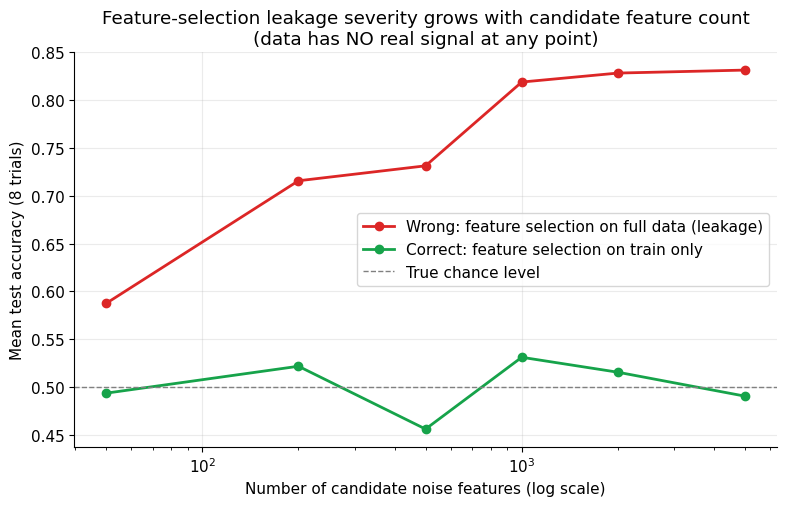

In [6]:
feature_counts = [50, 200, 500, 1000, 2000, 5000]
n_trials = 8
mean_wrong, mean_correct = [], []

for p in feature_counts:
    trial_w, trial_c = [], []
    for trial in range(n_trials):
        aw, ac = run_leakage_trial(n_samples=100, n_features=p, k_selected=15, seed=trial)
        trial_w.append(aw); trial_c.append(ac)
    mean_wrong.append(np.mean(trial_w))
    mean_correct.append(np.mean(trial_c))

plt.figure(figsize=(8, 5.2))
plt.plot(feature_counts, mean_wrong, "o-", color="#dc2626", linewidth=2,
          label="Wrong: feature selection on full data (leakage)")
plt.plot(feature_counts, mean_correct, "o-", color="#16a34a", linewidth=2,
          label="Correct: feature selection on train only")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="True chance level")
plt.xscale("log")
plt.xlabel("Number of candidate noise features (log scale)")
plt.ylabel("Mean test accuracy (8 trials)")
plt.title("Feature-selection leakage severity grows with candidate feature count\n(data has NO real signal at any point)")
plt.legend()
plt.tight_layout()
plt.show()


The leaked accuracy climbs steadily as the number of candidate features grows — more candidates
means more opportunities for `SelectKBest` to stumble on a spurious correlation that happens to
extend into the test fold. The correct pipeline stays pinned at chance level regardless of how
many candidate features exist, exactly as it should on data with no real signal. This single
experiment is, in miniature, the same mechanism Kapoor and Narayanan (2023) describe as the most
common and severe driver of inflated, irreproducible results in published machine-learning
research — and it grows *worse*, not better, as the feature space grows, which is exactly the
high-dimensional, small-sample regime common in genomics, neuroimaging, and text classification.


## 5. Two Documented Case Studies from the Literature

**Civil war prediction (political science).** Several influential papers claimed that complex
machine learning models substantially outperformed decades-old logistic regression at predicting
the onset of civil wars, reporting AUC scores above 0.90 versus roughly 0.78 for logistic
regression. A reproducibility audit by Kapoor and Narayanan (2023) identified multiple leakage
types in these papers — preprocessing before splitting (L2), imputation contamination, and proxy
features causally linked to the target (L5). After correcting these issues, the gap nearly
vanished: roughly 0.81 for the ML models versus roughly 0.80 for logistic regression. The original
headline claim — that modern ML decisively outperforms simple, well-understood baselines on this
problem — did not survive the correction.

**Neuroimaging connectomics.** Rosenblatt et al. (2024), published in *Nature Communications*,
quantified leakage effects across more than 400 machine-learning pipelines and four datasets in
brain-connectivity research. Feature-selection leakage produced the most severe inflation of all
the mechanisms studied, and leakage effects were consistently found to scale up sharply as sample
size shrank — precisely the high-dimensional, small-$n$ regime our own noise experiment above was
designed to probe.


## 6. The `Pipeline` and `ColumnTransformer`: A Structural Solution

The scikit-learn `Pipeline` resolves the fit/transform discipline problem *structurally*, by making
correct usage the only usage that is possible. Calling `pipe.fit(X_train, y_train)` internally
calls `fit_transform()` on every intermediate step using only the training data provided; calling
`pipe.predict(X_test)` or `pipe.score(X_test, y_test)` applies only `transform()` at every step,
using the parameters already frozen during `fit()`. Wrapped inside `cross_val_score` or
`GridSearchCV`, the pipeline is automatically and correctly refit on each individual training
fold — eliminating an entire class of leakage by construction, with no manual bookkeeping
required.


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

rng = np.random.default_rng(3)
n = 400
numeric_features = ["age", "income"]
categorical_features = ["city"]

demo_df = pd.DataFrame({
    "age": rng.normal(40, 12, n),
    "income": rng.lognormal(10, 0.8, n),
    "city": rng.choice(["Cairo", "Giza", "Alexandria"], size=n),
})
raw_score = demo_df["age"] * 0.02 + np.log1p(demo_df["income"]) * 0.3 + rng.normal(0, 1, n)
y_demo = (raw_score > np.median(raw_score)).astype(int)

numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                       ("encoder", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([("num", numeric_pipe, numeric_features),
                                     ("cat", cat_pipe, categorical_features)])
full_pipe = Pipeline([("preprocessor", preprocessor), ("classifier", GradientBoostingClassifier())])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(full_pipe, demo_df, y_demo, cv=cv, scoring="roc_auc")
print(f"Mean AUC across 5 folds (scaler/encoder/imputer re-fit independently per fold): "
      f"{scores.mean():.3f} +/- {scores.std():.3f}")


Mean AUC across 5 folds (scaler/encoder/imputer re-fit independently per fold): 0.624 +/- 0.069


## 7. Side-by-Side: Correct vs. Incorrect Workflows

| Step | Incorrect — causes leakage | Correct — no leakage |
|---|---|---|
| 1 | `scaler.fit_transform(X_full)` — fits on the full dataset | `X_tr, X_te, y_tr, y_te = train_test_split(...)` — split first |
| 2 | Split happens *after* scaling — already contaminated | `X_tr_scaled = scaler.fit_transform(X_tr)` — fit on train only |
| 3 | `model.fit(X_tr, y_tr)` on contaminated data | `X_te_scaled = scaler.transform(X_te)` — same learned $\phi^*$ |
| 4 | `model.score(X_te, y_te)` — inflated, overoptimistic | `model.fit(X_tr_scaled, y_tr)`; `model.score(X_te_scaled, y_te)` — honest |

## 8. Practitioner Decision Framework

- **Is this training data?** Yes → `fit_transform(X_train)`. No → `transform(X_test)` only, never `fit_transform`.
- **Using cross-validation?** Yes → wrap every preprocessing step inside a `Pipeline`; never fit anything outside the CV loop. No → ensure `fit()` was called exclusively on the training fold.
- **Time-series data?** Yes → use `TimeSeriesSplit`; chronological splitting is mandatory. No → `StratifiedKFold` is appropriate.
- **Grouped observations (patients, users, sessions)?** Yes → use `GroupKFold` to prevent non-independence leakage (L7). No → standard CV is fine.

**A short pre-publication checklist** (after Kapoor & Narayanan, 2023): Is there a held-out test
set that was never used for any modelling decision? Were all preprocessing steps fit exclusively
on the training partition? Was feature selection performed using only training labels? For
time-series, was the split strictly chronological? Are there any duplicate observations spanning
the train/test boundary? Are all features genuinely available at real prediction time? Is
train/test independence preserved (no shared subjects, families, or sessions)?


## 9. Conclusion

The distinction between `fit()`, `transform()`, and `fit_transform()` is not a software
convenience — it is the literal implementation of the Estimate-Transform separation principle that
underlies valid statistical evaluation. Our own experiment showed this with maximum clarity: on
data containing absolutely no genuine signal, a leaky feature-selection pipeline still produced
accuracy well above chance, and the severity of that illusion grew systematically with the number
of candidate features — mirroring the same high-dimensional, small-sample conditions implicated in
real published reproducibility failures, from civil war prediction models to neuroimaging
connectomics. The `Pipeline` and `ColumnTransformer` classes remove this entire failure mode by
construction, and should be the default, not the exception, in any serious machine learning
workflow.

**References**

- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12, 2825–2830.
- Buitinck, L. et al. (2013). *API Design for Machine Learning Software.* ECML PKDD Workshop.
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). *Leakage in Data Mining: Formulation, Detection, and Avoidance.* ACM TKDD, 6(4).
- Kapoor, S., & Narayanan, A. (2023). *Leakage and the Reproducibility Crisis in Machine-Learning-Based Science.* Patterns, 4(9), 100804.
- Rosenblatt, M. et al. (2024). *Data Leakage Inflates Prediction Performance in Connectome-Based Machine Learning Models.* Nature Communications, 15, 1829.
- Ambroise, C., & McLachlan, G. J. (2002). *Selection Bias in Gene Extraction on the Basis of Microarray Gene-Expression Data.* PNAS, 99(10).
- Scikit-learn Developers (2024). *Common Pitfalls and Recommended Practices.* Official documentation.
